In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [2]:
# Display config
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_style('whitegrid')
sns.set_palette('husl')

In [3]:
DATA_PATH = './IDN2015_Public_Use_national.csv'
df_raw = pd.read_csv(DATA_PATH)
df_raw.shape

(11142, 141)

# Kenalan ke dataset

In [4]:
df_raw.head()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20,Q21,Q22,Q23,Q24,Q25,...,qnfr2g,qnfr3g,qnveglg,qnveg1g,qnveg2g,qnveg3g,qnsodalg,qnsoda1g,qnsoda2g,qnsoda3g,qnff1g,qnff2g,qnff3g,qnc2g,qntob2g,qnnotb2g,qnbcanyg,qnc1g,qnpa5g,qnpa7g,qnpe3g,qnpe5g,weight,stratum,psu
0,1.00,1.00,1.00,1.57,41.00,3.00,1.00,4.00,1.00,8.00,4.00,4.00,5.00,5.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,2.00,2.00,...,2.00,2.00,2.00,1.00,1.00,2.00,2.00,2.00,2.00,2.00,1.00,1.00,1.00,NaN,2.00,1.00,NaN,NaN,2.00,2.00,2.00,2.00,1895.51,201501012,25
1,3.00,1.00,1.00,1.61,54.00,1.00,1.00,5.00,1.00,1.00,4.00,5.00,5.00,5.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,2.00,2.00,...,2.00,2.00,2.00,1.00,1.00,1.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,NaN,2.00,1.00,NaN,NaN,2.00,2.00,2.00,2.00,1895.51,201501012,25
2,2.00,2.00,1.00,1.52,46.00,3.00,5.00,4.00,1.00,1.00,4.00,4.00,5.00,5.00,3.00,1.00,NaN,NaN,NaN,1.00,1.00,1.00,1.00,2.00,2.00,...,1.00,1.00,2.00,1.00,1.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,NaN,2.00,1.00,NaN,NaN,2.00,2.00,2.00,2.00,1709.85,201501012,25
3,3.00,2.00,1.00,1.46,58.00,1.00,4.00,4.00,3.00,2.00,5.00,4.00,4.00,5.00,3.00,1.00,1.00,1.00,1.00,1.00,1.00,3.00,3.00,2.00,2.00,...,1.00,2.00,2.00,1.00,1.00,2.00,2.00,1.00,2.00,2.00,1.00,2.00,2.00,NaN,2.00,1.00,NaN,NaN,2.00,2.00,1.00,2.00,1709.85,201501012,25
4,2.00,2.00,1.00,1.47,48.00,1.00,3.00,5.00,1.00,1.00,4.00,4.00,4.00,4.00,3.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,2.00,2.00,...,2.00,2.00,2.00,1.00,1.00,1.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,NaN,2.00,1.00,NaN,NaN,2.00,2.00,2.00,2.00,1709.85,201501012,25


In [5]:
df_raw.describe()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20,Q21,Q22,Q23,Q24,Q25,...,qnfr2g,qnfr3g,qnveglg,qnveg1g,qnveg2g,qnveg3g,qnsodalg,qnsoda1g,qnsoda2g,qnsoda3g,qnff1g,qnff2g,qnff3g,qnc2g,qntob2g,qnnotb2g,qnbcanyg,qnc1g,qnpa5g,qnpa7g,qnpe3g,qnpe5g,weight,stratum,psu
count,11124.00,11110.00,11081.00,10554.00,10554.00,11091.00,11020.00,11087.00,11080.00,11077.00,11064.00,11121.00,11106.00,11059.00,11070.00,11042.00,10029.00,10479.00,10127.00,10363.00,10359.00,11030.00,11102.00,10977.00,10995.00,...,11020.00,11020.00,11087.00,11087.00,11087.00,11087.00,11080.00,11080.00,11080.00,11080.00,11077.00,11077.00,11077.00,464.00,10995.00,10933.00,130.00,275.00,10910.00,10910.00,10960.00,10960.00,11142.00,11142.00,11142.00
mean,4.03,1.54,2.78,1.53,45.55,2.05,3.11,3.72,2.07,2.02,4.24,4.29,4.38,3.95,1.62,1.44,1.48,1.88,1.66,1.34,1.86,2.13,2.02,1.94,1.94,...,1.66,1.85,1.84,1.19,1.44,1.73,1.66,1.72,1.91,1.96,1.47,1.76,1.88,1.56,1.88,1.11,1.44,1.77,1.84,1.88,1.87,1.91,1106.83,201502005.68,12.50
std,1.59,0.50,1.52,0.09,11.12,1.04,1.42,1.32,1.18,1.40,0.77,0.90,0.89,0.99,1.14,1.04,0.95,2.10,1.49,0.89,2.05,1.07,1.04,0.23,0.23,...,0.47,0.36,0.36,0.39,0.50,0.45,0.47,0.45,0.29,0.20,0.50,0.43,0.33,0.50,0.32,0.32,0.50,0.42,0.37,0.33,0.34,0.29,493.80,821.01,6.81
min,1.00,1.00,1.00,1.19,22.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,466.14,201501001.00,1.00
25%,3.00,1.00,2.00,1.47,38.00,1.00,2.00,3.00,1.00,1.00,4.00,4.00,4.00,3.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,2.00,2.00,...,1.00,2.00,2.00,1.00,1.00,1.00,1.00,1.00,2.00,2.00,1.00,2.00,2.00,1.00,2.00,1.00,1.00,2.00,2.00,2.00,2.00,2.00,745.41,201501010.00,7.00
50%,4.00,2.00,3.00,1.52,44.00,2.00,3.00,4.00,2.00,2.00,4.00,5.00,5.00,4.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,2.00,2.00,2.00,2.00,...,2.00,2.00,2.00,1.00,1.00,2.00,2.00,2.00,2.00,2.00,1.00,2.00,2.00,2.00,2.00,1.00,1.00,2.00,2.00,2.00,2.00,2.00,873.06,201502006.00,12.00
75%,5.00,2.00,4.00,1.58,51.00,3.00,4.00,5.00,3.00,2.00,5.00,5.00,5.00,5.00,2.00,1.00,2.00,1.00,1.00,1.00,1.00,3.00,3.00,2.00,2.00,...,2.00,2.00,2.00,1.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,1.00,2.00,2.00,2.00,2.00,2.00,2.00,1658.04,201503004.00,18.00
max,8.00,2.00,6.00,1.96,130.00,5.00,7.00,7.00,7.00,8.00,6.00,5.00,5.00,5.00,8.00,8.00,8.00,8.00,8.00,7.00,8.00,5.00,5.00,2.00,2.00,...,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2929.30,201503012.00,25.00


In [6]:
# Rangkuman missing value dataset
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
}).sort_values('Persentase (%)', ascending=False)

print('Kolom dengan missing value terbanyak (top 20):')
print(missing_df[missing_df['Jumlah Missing'] > 0].head(20))

print(f'\nTotal kolom dengan missing value : {(missing > 0).sum()}')
print(f'Total kolom tanpa missing value  : {(missing == 0).sum()}')

Kolom dengan missing value terbanyak (top 20):
          Jumlah Missing  Persentase (%)
qnbcanyg           11012           98.83
QN45               10962           98.38
QN47               10951           98.29
QN48               10936           98.15
QN40               10871           97.57
qnc1g              10867           97.53
qnc2g              10678           95.84
QN37               10651           95.59
QN36               10526           94.47
QN34               10230           91.81
QN31                9769           87.68
QN21                9317           83.62
QN28                8908           79.95
QN18                8799           78.97
QN19                8666           77.78
QN44                1613           14.48
Q44                 1613           14.48
Q47                 1268           11.38
QN17                1113            9.99
Q17                 1113            9.99

Total kolom dengan missing value : 138
Total kolom tanpa missing value  : 3


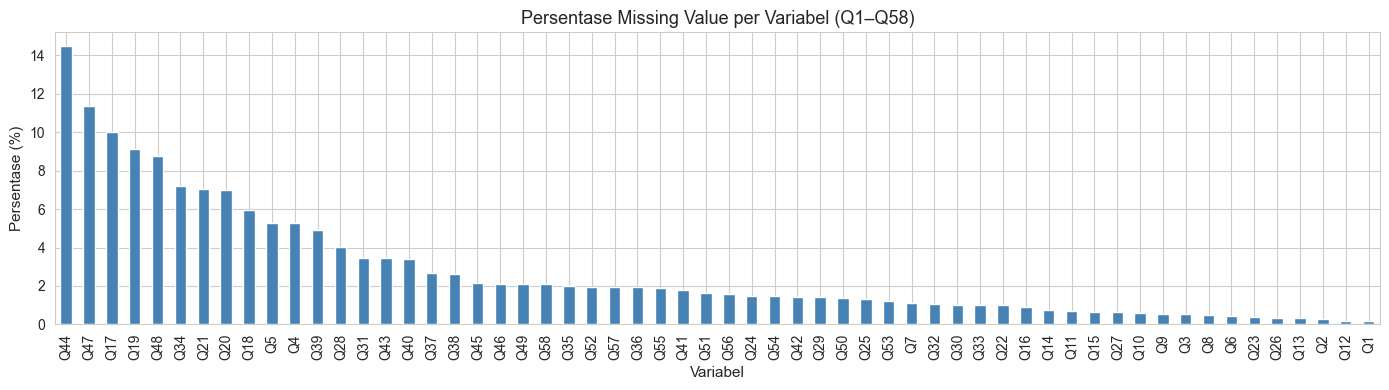

In [7]:
q_cols = [c for c in df_raw.columns if c.startswith('Q') and not c.startswith('QN')]

# Bar plot persentase missing per kolom Q
missing_q = missing_pct[q_cols].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(14, 4))
missing_q.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Persentase Missing Value per Variabel (Q1–Q58)')
ax.set_ylabel('Persentase (%)')
ax.set_xlabel('Variabel')
plt.tight_layout()
plt.show()

# Pemetaan key variable

In [8]:
VAR_MAP = {
    # DEMOGRAFIS
    'Q1':  'Usia (1=≤11thn ... 8=≥18thn)',
    'Q2':  'Jenis kelamin (1=Laki-laki, 2=Perempuan)',
    'Q3':  'Kelas (1=Kelas7 ... 6=Kelas12)',
    'Q4':  'Tinggi badan (meter)',
    'Q5':  'Berat badan (kg)',

    # MENTAL HEALTH
    'Q22': 'Perasaan kesepian — 12 bulan terakhir (1=Tidak pernah ... 4=Seringkali)',
    'Q23': 'Khawatir sampai tidak bisa tidur — 12 bulan terakhir (1=Tidak pernah ... 4=Seringkali)',
    'Q24': 'Pernah berpikir serius untuk bunuh diri (1=Tidak pernah ... >1=Pernah)',
    'Q25': 'Pernah membuat rencana bunuh diri (1=Tidak/0 ... 5=5+ kali)',
    'Q26': 'Jumlah percobaan bunuh diri (1=0 kali, 2=1 kali, ...)',
    'Q27': 'Jumlah teman dekat (1=0, 2=1, 3=2, 4=3 atau lebih)',

    # BULLYING & KEKERASAN
    'Q15': 'Jumlah kali diserang fisik — 12 bulan (1=0 kali ... 5=6-7 kali+)',
    'Q16': 'Jumlah perkelahian fisik — 12 bulan (1=0 kali ... 5=6+ kali)',
    'Q20': 'Hari di-bully — 30 hari terakhir (1=0 hari, 2=1-2 hari, ...)',
    'Q21': 'Cara di-bully paling sering',

    # PENGGUNAAN ZAT
    'Q28': 'Usia pertama kali merokok',
    'Q29': 'Hari merokok — 30 hari terakhir (1=0 hari, 2=1-2 hari, ...)',
    'Q34': 'Usia pertama kali minum alkohol',
    'Q35': 'Hari minum alkohol — 30 hari terakhir',
    'Q38': 'Berapa kali minum sampai teler seumur hidup',
    'Q40': 'Usia pertama kali menggunakan narkoba',

    # VARIABEL DERIVED (BINARY: 1=Ya/Berisiko, 2=Tidak)
    'QN22': 'Sering/selalu kesepian [binary]',
    'QN23': 'Sering/selalu khawatir-insomnia [binary]',
    'QN24': 'Pernah mempertimbangkan bunuh diri [binary]',
    'QN25': 'Pernah merencanakan bunuh diri [binary]',
    'QN26': 'Pernah mencoba bunuh diri [binary]',
    'QN20': 'Di-bully (≥1 hari/bulan) [binary]',
    'QN15': 'Diserang fisik [binary]',
    'QN30': 'Perokok aktif [binary]',
    'QN35': 'Peminum alkohol [binary]',
    'QN42': 'Pengguna narkoba [binary]',
    'qnpe3g': 'Aktif fisik ≥3 hari/minggu [binary]',
    'qnpe5g': 'Aktif fisik ≥5 hari/minggu [binary]',
}

pd.DataFrame.from_dict(VAR_MAP, orient='index', columns=['Deskripsi'])

,Deskripsi
Q1,Usia (1=≤11thn ... 8=≥18thn)
Q2,"Jenis kelamin (1=Laki-laki, 2=Perempuan)"
Q3,Kelas (1=Kelas7 ... 6=Kelas12)
Q4,Tinggi badan (meter)
Q5,Berat badan (kg)
Q22,Perasaan kesepian — 12 bulan terakhir (1=Tidak...
Q23,Khawatir sampai tidak bisa tidur — 12 bulan te...
Q24,Pernah berpikir serius untuk bunuh diri (1=Tid...
Q25,Pernah membuat rencana bunuh diri (1=Tidak/0 ....
Q26,"Jumlah percobaan bunuh diri (1=0 kali, 2=1 kal..."


In [9]:
df_raw['QN38'].value_counts()

QN38
2.00    10460
1.00      388
Name: count, dtype: int64

# EDA

## Demografis

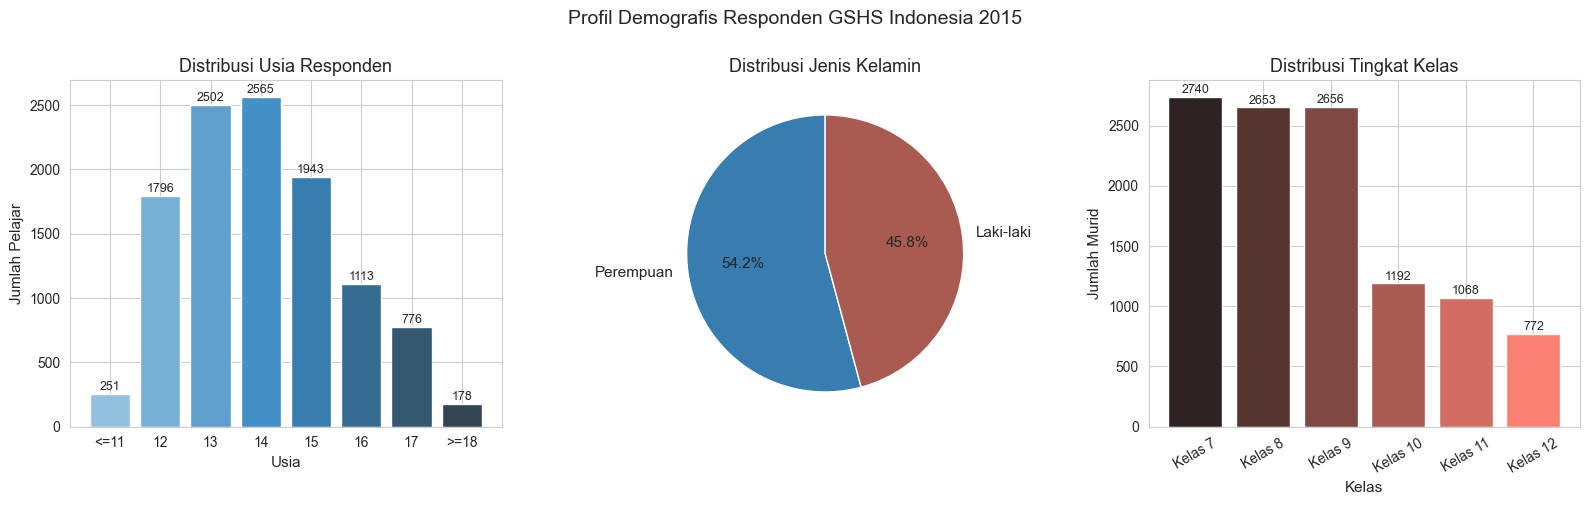

In [10]:
usia_label = {1: '<=11', 2: '12', 3: '13', 4: '14', 5: '15', 6: '16', 7: '17', 8: '>=18'}
kelamin_label = {1: 'Laki-laki', 2: 'Perempuan'}
kelas_label = {1: 'Kelas 7', 2: 'Kelas 8', 3: 'Kelas 9', 4: 'Kelas 10',
               5: 'Kelas 11', 6: 'Kelas 12'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribusi Usia
usia_counts = df_raw['Q1'].map(usia_label).value_counts().sort_index()
usia_counts = df_raw['Q1'].dropna().map(usia_label)
order = ['<=11', '12', '13', '14', '15', '16', '17', '>=18']
usia_plot = df_raw['Q1'].dropna().map(usia_label).value_counts().reindex(order).fillna(0)
axes[0].bar(usia_plot.index, usia_plot.values, color=sns.color_palette('Blues_d', 8))
axes[0].set_title('Distribusi Usia Responden')
axes[0].set_xlabel('Usia')
axes[0].set_ylabel('Jumlah Pelajar')
for i, v in enumerate(usia_plot.values):
    axes[0].text(i, v + 30, str(int(v)), ha='center', fontsize=9)

# Distribusi Kelamin
kelamin_counts = df_raw['Q2'].dropna().map(kelamin_label).value_counts()
colors = ['#377DB0', '#A95B52']
axes[1].pie(kelamin_counts.values, labels=kelamin_counts.index, autopct='%1.1f%%', colors=colors,
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Distribusi Jenis Kelamin')

# Distribusi Grade
kelas_counts = df_raw['Q3'].dropna().map(kelas_label).value_counts()
kelas_order = ['Kelas 7', 'Kelas 8', 'Kelas 9', 'Kelas 10', 'Kelas 11', 'Kelas 12']
kelas_plot = kelas_counts.reindex(kelas_order).fillna(0)
axes[2].bar(kelas_plot.index, kelas_plot.values, color=sns.color_palette('dark:salmon', 6))
axes[2].set_title('Distribusi Tingkat Kelas')
axes[2].set_xlabel('Kelas')
axes[2].set_ylabel('Jumlah Murid')
axes[2].tick_params(axis='x', rotation=30)
for i, v in enumerate(kelas_plot.values):
    axes[2].text(i, v + 30, str(int(v)), ha='center', fontsize=9)

plt.suptitle('Profil Demografis Responden GSHS Indonesia 2015', fontsize=14, y=1)
plt.tight_layout()
plt.show()

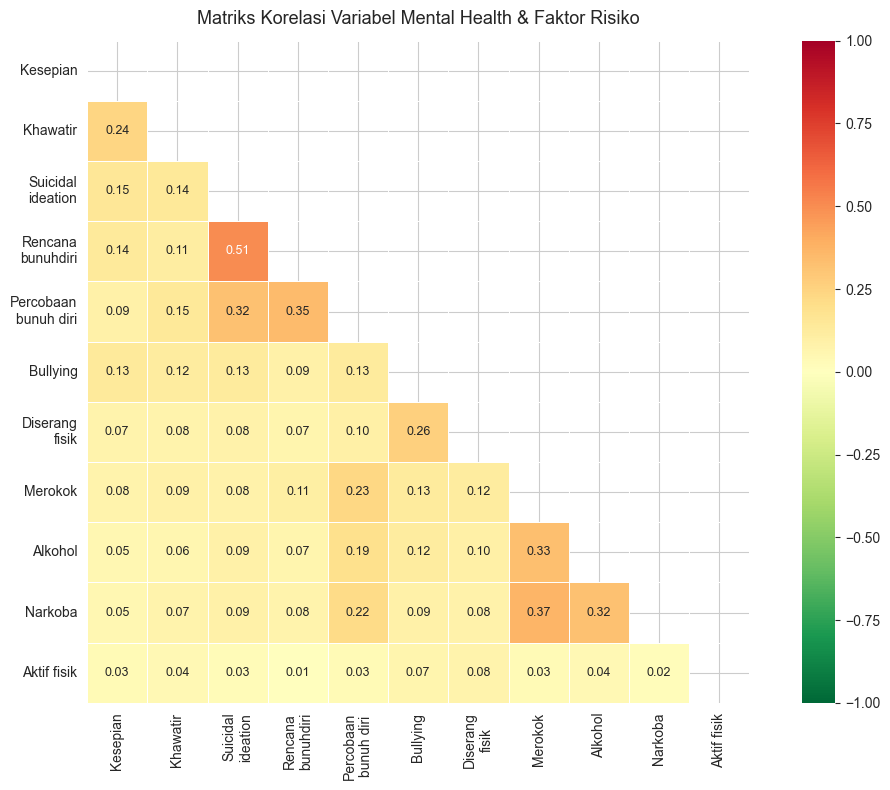

In [11]:
# Heatmap
corr_cols = ['QN22', 'QN23', 'QN24', 'QN25', 'QN26', 'QN20', 'QN15', 'QN30', 'QN35', 'QN42', 'qnpe3g']
corr_labels = ['Kesepian', 'Khawatir', 'Suicidal\nideation', 'Rencana\nbunuhdiri', 'Percobaan\nbunuh diri',
               'Bullying', 'Diserang\nfisik', 'Merokok', 'Alkohol', 'Narkoba', 'Aktif fisik']

# Subset data, konversi ke numerik (1=Ya/Berisiko -> 1, 2=Tidak -> 0)
df_corr = df_raw[corr_cols].copy()
# QN cols: 1=berisiko, 2=tidak -> kita buat 1=berisiko, 0=tidak
df_corr = df_corr.apply(lambda col: col.map({1: 1, 2: 0}))
df_corr.columns = corr_labels

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Matriks Korelasi Variabel Mental Health & Faktor Risiko', pad=12)
plt.tight_layout()
plt.show()

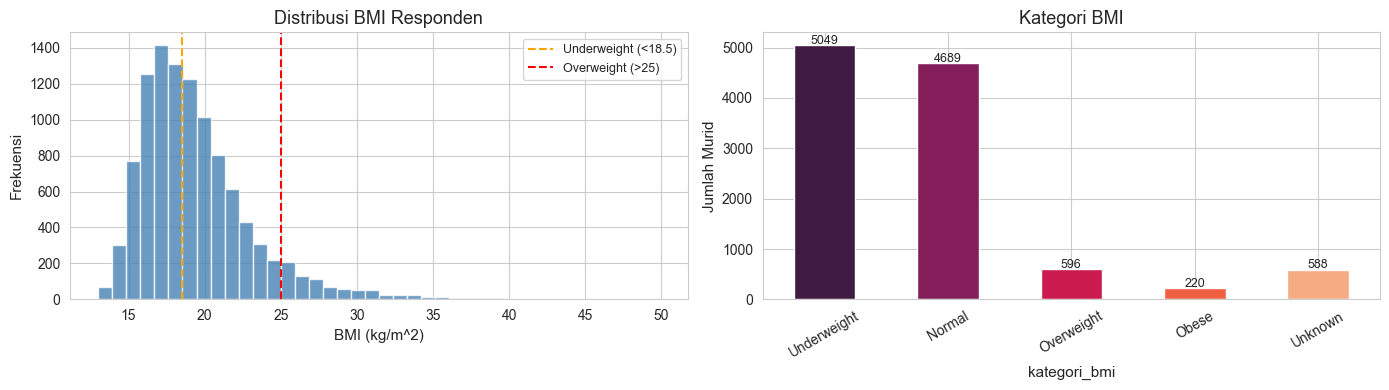

count   10553.00
mean       19.42
std         3.72
min        13.01
25%        16.89
50%        18.66
75%        20.96
max        49.88
Name: bmi, dtype: float64

In [12]:
# BMI
df_bmi = df_raw[['Q4', 'Q5']].copy()
df_bmi.columns = ['tinggi (m)', 'berat (kg)']
df_bmi['bmi'] = df_bmi['berat (kg)'] / (df_bmi['tinggi (m)'] ** 2)
bmi_valid = df_bmi['bmi'][(df_bmi['bmi'] >= 10) & (df_bmi['bmi'] <= 50)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(bmi_valid, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x=18.5, color='orange', linestyle='--', label='Underweight (<18.5)')
axes[0].axvline(x=25.0, color='red', linestyle='--', label='Overweight (>25)')
axes[0].set_title('Distribusi BMI Responden')
axes[0].set_xlabel('BMI (kg/m^2)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend(fontsize=9)

def bmi_cat(bmi):
    if pd.isna(bmi): return 'Unknown'
    elif bmi < 18.5: return 'Underweight'
    elif bmi < 25.0: return 'Normal'
    elif bmi < 30.0: return 'Overweight'
    else: return 'Obese'

df_bmi['kategori_bmi'] = df_bmi['bmi'].apply(bmi_cat)
bmi_cat_counts = df_bmi['kategori_bmi'].value_counts()
bmi_order = ['Underweight', 'Normal', 'Overweight', 'Obese', 'Unknown']
bmi_cat_plot = bmi_cat_counts.reindex(bmi_order).fillna(0)
bmi_cat_plot.plot(kind='bar', ax=axes[1], color=sns.color_palette('rocket', 5), edgecolor='white')
axes[1].set_title('Kategori BMI')
axes[1].set_ylabel('Jumlah Murid')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(bmi_cat_plot.values):
    axes[1].text(i, v + 30, str(int(v)), ha='center', fontsize=9)

plt.tight_layout()
plt.show()
bmi_valid.describe()

## Mental Health

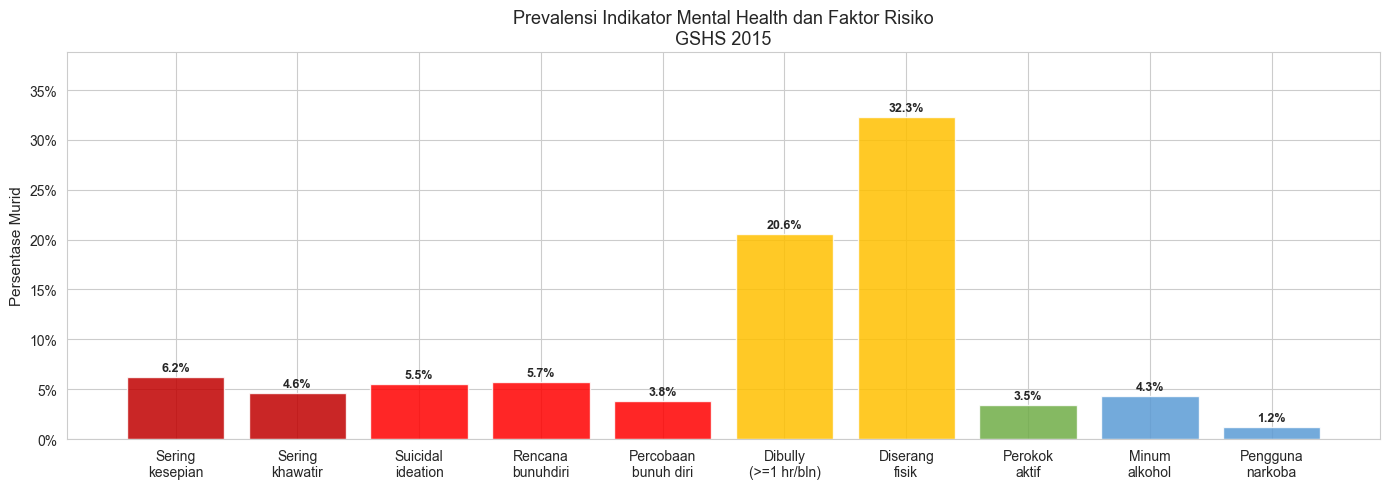

            Indikator  Prevalensi (%)  Jumlah Murid
     Sering\nkesepian            6.25           689
     Sering\nkhawatir            4.64           515
   Suicidal\nideation            5.50           604
   Rencana\nbunuhdiri            5.71           628
Percobaan\nbunuh diri            3.79           421
Dibully\n(>=1 hr/bln)           20.59          2134
      Diserang\nfisik           32.33          3579
       Perokok\naktif            3.45           381
       Minum\nalkohol            4.33           473
    Pengguna\nnarkoba            1.18           130


In [13]:
mh_bin_cols = ['QN22', 'QN23', 'QN24', 'QN25', 'QN26', 'QN20', 'QN15', 'QN30', 'QN35', 'QN42']
mh_bin_label = [
    'Sering\nkesepian',
    'Sering\nkhawatir',
    'Suicidal\nideation',
    'Rencana\nbunuhdiri',
    'Percobaan\nbunuh diri',
    'Dibully\n(>=1 hr/bln)',
    'Diserang\nfisik',
    'Perokok\naktif',
    'Minum\nalkohol',
    'Pengguna\nnarkoba'
]

prevalensi = []
for col in mh_bin_cols:
    pct = (df_raw[col] == 1).sum() / df_raw[col].notna().sum() * 100
    prevalensi.append(pct)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(mh_bin_label, prevalensi,
              color=['#C00000', '#C00000', '#FF0000', '#FF0000', '#FF0000',
                    '#FFC000', '#FFC000', '#70AD47', '#5B9BD5', '#5B9BD5'],
              edgecolor='white', alpha=0.85)

for bar, pct in zip(bars, prevalensi):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Prevalensi Indikator Mental Health dan Faktor Risiko\nGSHS 2015', fontsize=13)
ax.set_ylabel('Persentase Murid')
ax.set_ylim(0, max(prevalensi) * 1.2)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
plt.tight_layout()
plt.show()

prev_df = pd.DataFrame({'Indikator': mh_bin_label, 'Prevalensi (%)': prevalensi})
prev_df['Jumlah Murid'] = [(df_raw[c] == 1).sum() for c in mh_bin_cols]
print(prev_df.to_string(index=False))

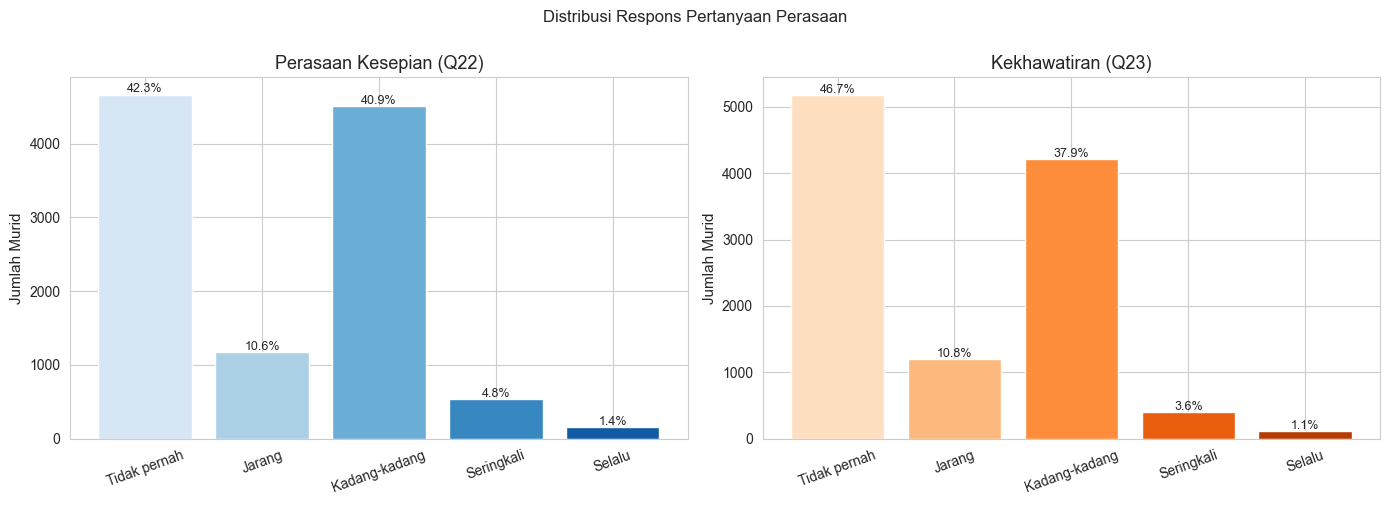

In [14]:
# Detail Q22 (Kesepian) dan Q23 (Khawatir)

lonely_label = {1: 'Tidak pernah', 2: 'Jarang', 3: 'Kadang-kadang', 4: 'Seringkali', 5: 'Selalu'}
worried_label = {1: 'Tidak pernah', 2: 'Jarang', 3: 'Kadang-kadang', 4: 'Seringkali', 5: 'Selalu'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, labels, title, color in zip(
    axes,
    ['Q22', 'Q23'],
    [lonely_label, worried_label],
    ['Perasaan Kesepian (Q22)', 'Kekhawatiran (Q23)'],
    ['Blues', 'Oranges']
):
    counts = df_raw[col].dropna().map(labels).value_counts()
    order = list(labels.values())
    plot_data = counts.reindex(order).fillna(0)
    ax.bar(plot_data.index, plot_data.values, color=sns.color_palette(color, len(order)),
           edgecolor='white')
    ax.set_title(title)
    ax.set_ylabel('Jumlah Murid')
    ax.tick_params(axis='x', rotation=20)
    total = plot_data.sum()
    for i, v in enumerate(plot_data.values):
        ax.text(i, v + 30, f'{v/total*100:.1f}%', ha='center', fontsize=9)

plt.suptitle('Distribusi Respons Pertanyaan Perasaan', fontsize=12, y=1)
plt.tight_layout()
plt.show()

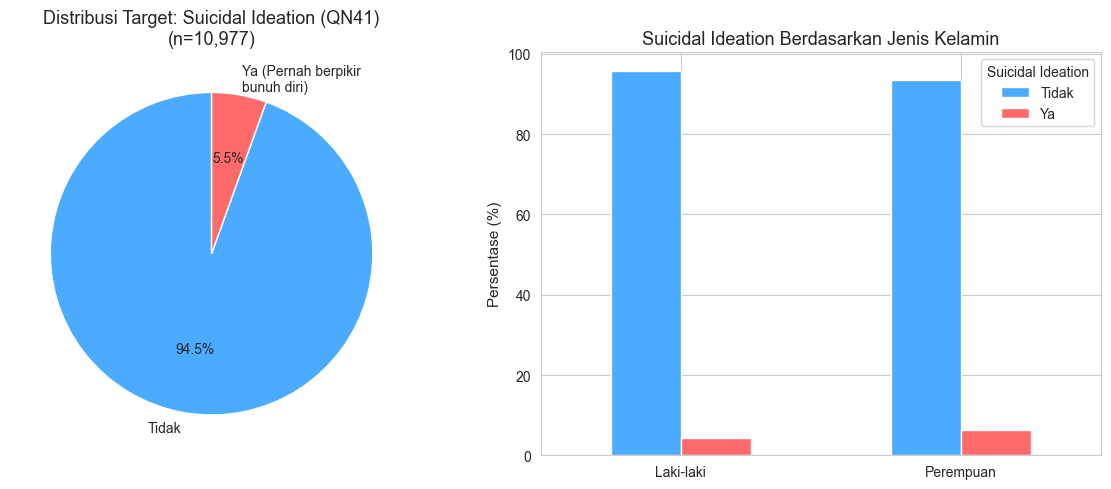

In [15]:
# Suicidal
target_col = 'QN24'
target_labels = {1: 'Ya (Pernah berpikir\nbunuh diri)', 2: 'Tidak'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart distribusi
counts = df_raw[target_col].dropna().map(target_labels).value_counts()
axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#4AABFF', '#FF6B6B'], startangle=90, textprops={'fontsize': 10})
axes[0].set_title(f'Distribusi Target: Suicidal Ideation (QN41)\n(n={df_raw[target_col].notna().sum():,})')

# Berdasarkan jenis kelamin
df_temp = df_raw[[target_col, 'Q2']].dropna()
df_temp['target'] = df_temp[target_col].map({1: 'Ya', 2: 'Tidak'})
df_temp['sex']    = df_temp['Q2'].map({1: 'Laki-laki', 2: 'Perempuan'})

cross = pd.crosstab(df_temp['sex'], df_temp['target'], normalize='index') * 100
cross.plot(kind='bar', ax=axes[1], color=['#4AABFF', '#FF6B6B'], edgecolor='white')
axes[1].set_title('Suicidal Ideation Berdasarkan Jenis Kelamin')
axes[1].set_ylabel('Persentase (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Suicidal Ideation')

plt.tight_layout()
plt.show()

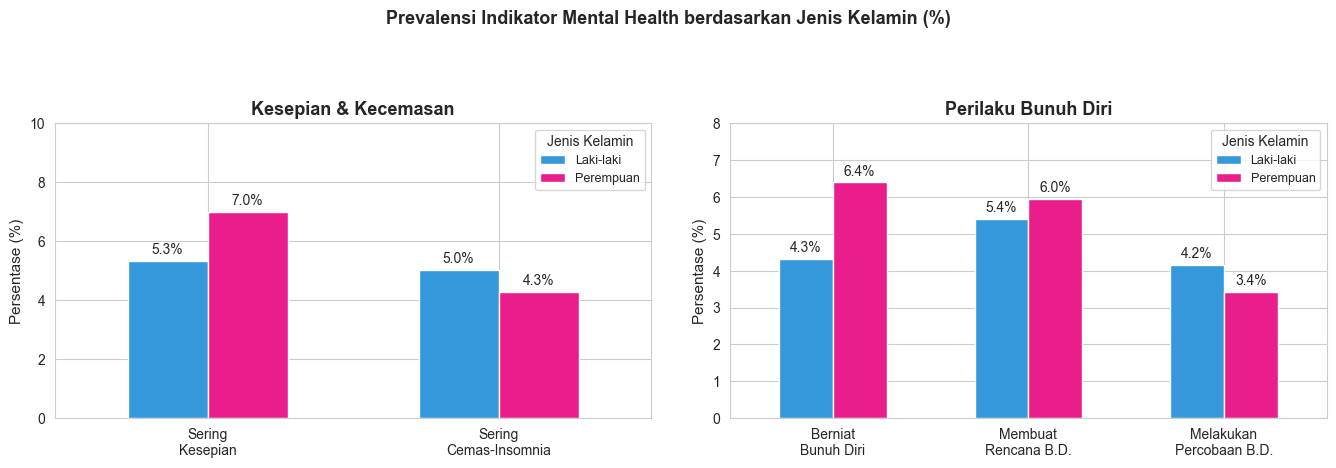

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Prevalensi Indikator Mental Health berdasarkan Jenis Kelamin (%)',
    fontsize=13, fontweight='bold'
)

gender_map = {1: 'Laki-laki', 2: 'Perempuan'}
gender_palette = ['#3498db', '#e91e8c']

# Kesepian dan Kecemasan
g1_items = {
    'QN22': 'Sering\nKesepian',
    'QN23': 'Sering\nCemas-Insomnia',
}

g1_result = {}

for col, label in g1_items.items():
    df_temp = df_raw[[col, 'Q2']].dropna()

    df_temp['target'] = df_temp[col].map({1: 'Ya', 2: 'Tidak'})
    df_temp['sex'] = df_temp['Q2'].map(gender_map)

    cross = pd.crosstab(df_temp['sex'], df_temp['target'], normalize='index') * 100
    g1_result[label] = cross['Ya']

g1_df = pd.DataFrame(g1_result).T

g1_df.plot(kind='bar', ax=axes[0],
           color=gender_palette,
           edgecolor='white', width=0.55)

axes[0].set_title('Kesepian & Kecemasan', fontweight='bold')
axes[0].set_ylabel('Persentase (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Jenis Kelamin', fontsize=9)
axes[0].set_ylim(0, 10)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', padding=3, fontsize=10)

# Perilaku bunuh diri
g2_items = {
    'QN24': 'Berniat\nBunuh Diri',
    'QN25': 'Membuat\nRencana B.D.',
    'QN26': 'Melakukan\nPercobaan B.D.',
}

g2_result = {}

for col, label in g2_items.items():
    df_temp = df_raw[[col, 'Q2']].dropna()

    df_temp['target'] = df_temp[col].map({1: 'Ya', 2: 'Tidak'})
    df_temp['sex'] = df_temp['Q2'].map(gender_map)

    cross = pd.crosstab(df_temp['sex'], df_temp['target'], normalize='index') * 100

    g2_result[label] = cross['Ya']

g2_df = pd.DataFrame(g2_result).T

g2_df.plot(kind='bar', ax=axes[1],
           color=gender_palette,
           edgecolor='white', width=0.55)

axes[1].set_title('Perilaku Bunuh Diri', fontweight='bold')
axes[1].set_ylabel('Persentase (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Jenis Kelamin', fontsize=9)
axes[1].set_ylim(0, 8)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', padding=3, fontsize=10)

plt.tight_layout(pad=3)
plt.show()

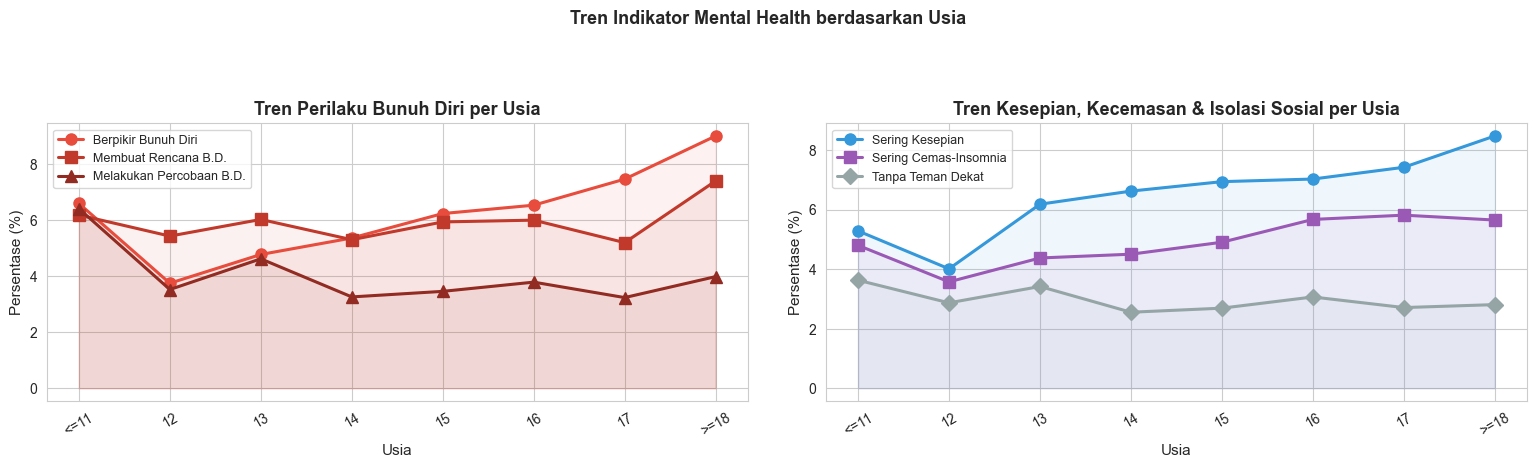

In [17]:
usia_order = ['<=11', '12', '13', '14', '15', '16', '17', '>=18']
usia_label = {1: '<=11', 2: '12', 3: '13', 4: '14', 5: '15', 6: '16', 7: '17', 8: '>=18'}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(
    'Tren Indikator Mental Health berdasarkan Usia',
    fontsize=13, fontweight='bold'
)

# Perilaku bunuh diri
trend_suicidal = {
    'QN24': ('Berpikir Bunuh Diri', '#e74c3c', 'o'),
    'QN25': ('Membuat Rencana B.D.', '#c0392b', 's'),
    'QN26': ('Melakukan Percobaan B.D.', '#922b21', '^'),
}

for col, (lbl, color, marker) in trend_suicidal.items():
    df_temp = df_raw[[col, 'Q1']].dropna().copy()

    df_temp['target'] = df_temp[col].map({1: 'Ya', 2: 'Tidak'})
    df_temp['usia']   = df_temp['Q1'].map(usia_label)

    cross = pd.crosstab(df_temp['usia'], df_temp['target'], normalize='index') * 100

    vals = cross.get('Ya', pd.Series(index=cross.index, data=0))
    vals = vals.reindex(usia_order)

    axes[0].plot(usia_order, vals.values, marker=marker, color=color,
                 label=lbl, linewidth=2.2, markersize=8)
    axes[0].fill_between(usia_order, vals.values, alpha=0.07, color=color)

axes[0].set_title('Tren Perilaku Bunuh Diri per Usia', fontweight='bold')
axes[0].set_ylabel('Persentase (%)')
axes[0].set_xlabel('Usia')
axes[0].legend(fontsize=9)
axes[0].tick_params(axis='x', rotation=30)

# Kesepian dkk
trend_mh2 = {
    'QN22': ('Sering Kesepian', '#3498db', 'o'),
    'QN23': ('Sering Cemas-Insomnia', '#9b59b6', 's'),
    'QN27': ('Tanpa Teman Dekat', '#95a5a6', 'D'),
}

for col, (lbl, color, marker) in trend_mh2.items():
    df_temp = df_raw[[col, 'Q1']].dropna().copy()

    df_temp['target'] = df_temp[col].map({1: 'Ya', 2: 'Tidak'})
    df_temp['usia']   = df_temp['Q1'].map(usia_label)

    cross = pd.crosstab(df_temp['usia'], df_temp['target'], normalize='index') * 100

    vals = cross.get('Ya', pd.Series(index=cross.index, data=0))
    vals = vals.reindex(usia_order)

    axes[1].plot(usia_order, vals.values, marker=marker, color=color,
                 label=lbl, linewidth=2.2, markersize=8)
    axes[1].fill_between(usia_order, vals.values, alpha=0.07, color=color)

axes[1].set_title('Tren Kesepian, Kecemasan & Isolasi Sosial per Usia', fontweight='bold')
axes[1].set_ylabel('Persentase (%)')
axes[1].set_xlabel('Usia')
axes[1].legend(fontsize=9)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout(pad=3)
plt.show()

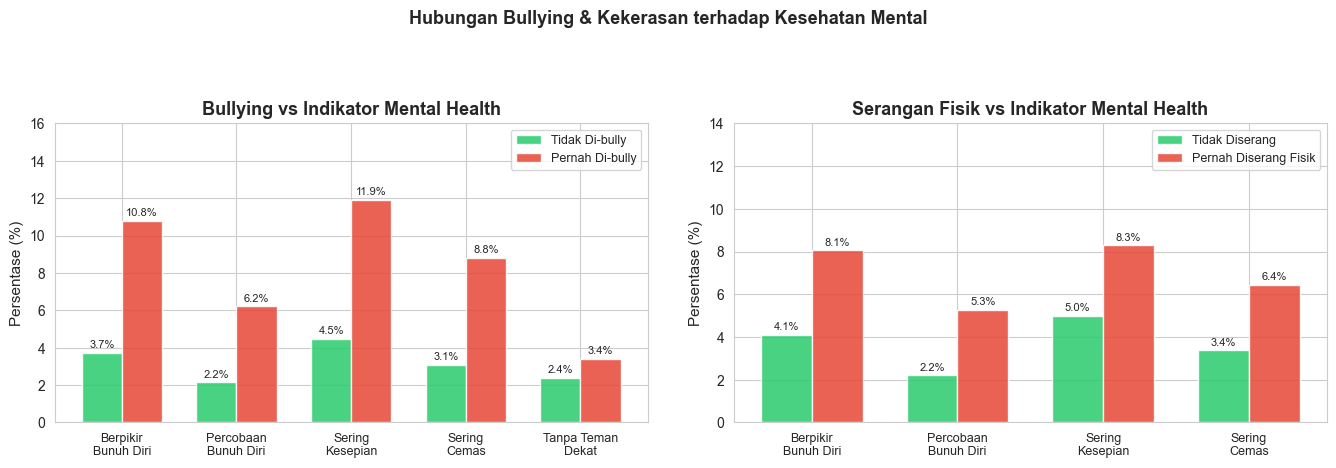

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Hubungan Bullying & Kekerasan terhadap Kesehatan Mental',
    fontsize=13, fontweight='bold'
)

outcome_labels = {
    'QN24': 'Berpikir\nBunuh Diri',
    'QN26': 'Percobaan\nBunuh Diri',
    'QN22': 'Sering\nKesepian',
    'QN23': 'Sering\nCemas',
    'QN27': 'Tanpa Teman\nDekat',
}
outcomes   = list(outcome_labels.keys())
out_labels = list(outcome_labels.values())
x_pos = np.arange(len(outcomes))
width = 0.35

# Bullying
cols_bully = ['QN20'] + outcomes
df_bully = df_raw[cols_bully].dropna().copy()
df_bully['kategori_bully'] = df_bully['QN20'].map({1: 'Pernah Di-bully', 2: 'Tidak Di-bully'})

for o in outcomes:
    df_bully[o + '_num'] = df_bully[o].map({1: 1, 2: 0})

pal_bully = {'Tidak Di-bully': '#2ecc71', 'Pernah Di-bully': '#e74c3c'}

for i, (lbl, color) in enumerate(pal_bully.items()):
    sub  = df_bully[df_bully['kategori_bully'] == lbl]
    pcts = [sub[o + '_num'].mean() * 100 for o in outcomes]
    
    bars = axes[0].bar(x_pos + i*width - width/2, pcts, width,
                       label=lbl, color=color, edgecolor='white', alpha=0.88)
    axes[0].bar_label(bars, fmt='%.1f%%', padding=2, fontsize=8)

axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(out_labels, fontsize=9)
axes[0].set_title('Bullying vs Indikator Mental Health', fontweight='bold')
axes[0].set_ylabel('Persentase (%)')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 16)

# Diserang fisik
outcomes_a = ['QN24','QN26','QN22','QN23']
x_pos_a = np.arange(len(outcomes_a))

cols_fisik = ['QN15'] + outcomes_a
df_fisik = df_raw[cols_fisik].dropna().copy()

df_fisik['kategori_fisik'] = df_fisik['QN15'].map({1: 'Pernah Diserang Fisik', 2: 'Tidak Diserang'})

for o in outcomes_a:
    df_fisik[o + '_num'] = df_fisik[o].map({1: 1, 2: 0})

pal_fisik = {'Tidak Diserang': '#2ecc71', 'Pernah Diserang Fisik': '#e74c3c'}

for i, (lbl, color) in enumerate(pal_fisik.items()):
    sub  = df_fisik[df_fisik['kategori_fisik'] == lbl]
    pcts = [sub[o + '_num'].mean() * 100 for o in outcomes_a]
    
    bars = axes[1].bar(x_pos_a + i*width - width/2, pcts, width,
                       label=lbl, color=color, edgecolor='white', alpha=0.88)
    axes[1].bar_label(bars, fmt='%.1f%%', padding=2, fontsize=8)

axes[1].set_xticks(x_pos_a)
axes[1].set_xticklabels(
    ['Berpikir\nBunuh Diri','Percobaan\nBunuh Diri','Sering\nKesepian','Sering\nCemas'],
    fontsize=9
)
axes[1].set_title('Serangan Fisik vs Indikator Mental Health', fontweight='bold')
axes[1].set_ylabel('Persentase (%)')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 14)

plt.tight_layout(pad=3)
plt.show()

## Risk Factors

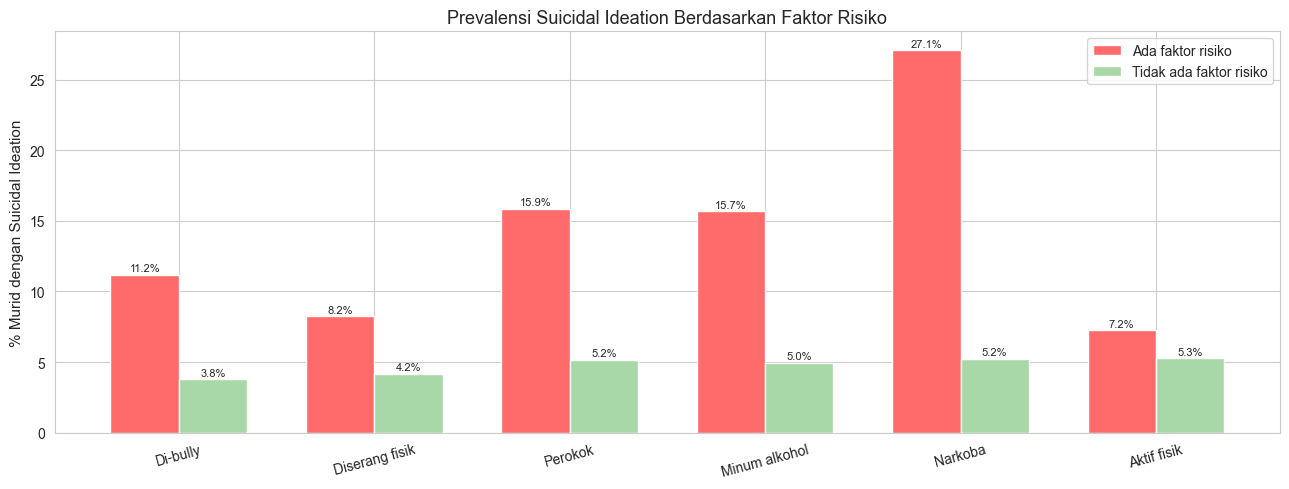

In [19]:
risk_factors = {
    'Di-bully': 'QN20',
    'Diserang fisik': 'QN15',
    'Perokok': 'QN30',
    'Minum alkohol': 'QN35',
    'Narkoba': 'QN42',
    'Aktif fisik': 'qnpe3g',
}

results = []
for label, col in risk_factors.items():
    if col not in df_raw.columns:
        continue
    df_temp = df_raw[[col, 'QN24']].dropna()
    # Berisiko = 1, Tidak = 2 (untuk QN cols)
    berisiko = df_temp[df_temp[col] == 1]
    tidak    = df_temp[df_temp[col] == 2]
    pct_berisiko = (berisiko['QN24'] == 1).mean() * 100
    pct_tidak    = (tidak['QN24'] == 1).mean() * 100
    results.append({
        'Faktor Risiko': label,
        'Ada faktor risiko (%)': pct_berisiko,
        'Tidak ada faktor risiko (%)': pct_tidak,
        'Rasio': pct_berisiko / pct_tidak if pct_tidak > 0 else np.nan
    })

results_df = pd.DataFrame(results)

x = np.arange(len(results_df))
width = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - width/2, results_df['Ada faktor risiko (%)'],    width, label='Ada faktor risiko',    color='#FF6B6B', edgecolor='white')
b2 = ax.bar(x + width/2, results_df['Tidak ada faktor risiko (%)'], width, label='Tidak ada faktor risiko', color='#A8D8A8', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Faktor Risiko'], rotation=15)
ax.set_ylabel('% Murid dengan Suicidal Ideation')
ax.set_title('Prevalensi Suicidal Ideation Berdasarkan Faktor Risiko')
ax.legend()
for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

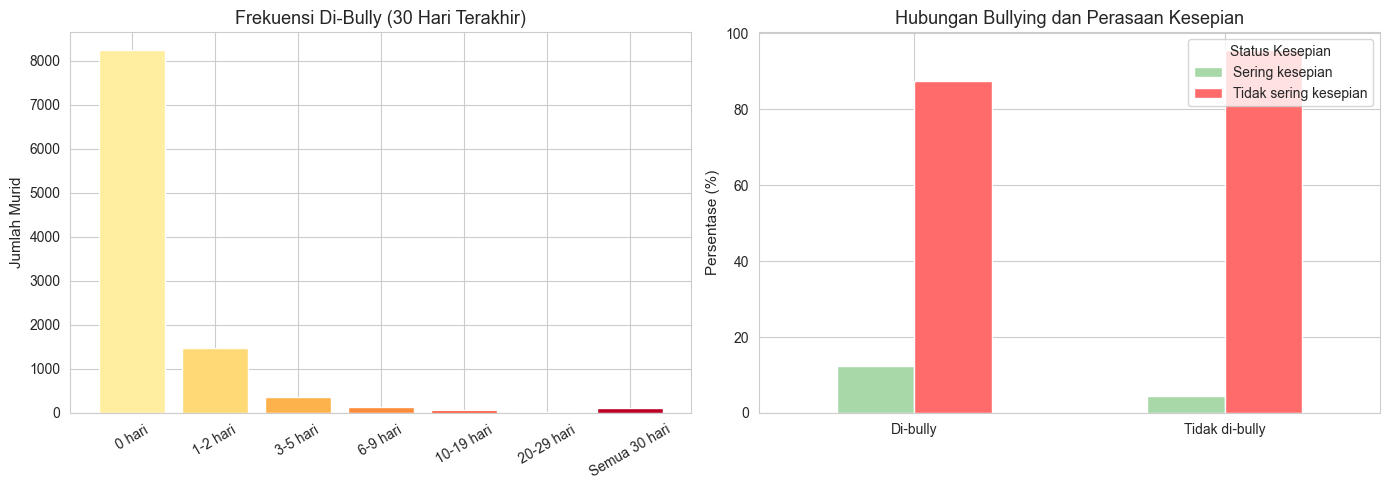

In [20]:
# Bullying
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi hari
bully_labels = {1: '0 hari', 2: '1-2 hari', 3: '3-5 hari', 4: '6-9 hari', 
                5: '10-19 hari', 6: '20-29 hari', 7: 'Semua 30 hari'}
bully_counts = df_raw['Q20'].dropna().map(bully_labels).value_counts()
bully_order  = list(bully_labels.values())
bully_plot   = bully_counts.reindex(bully_order).fillna(0)
axes[0].bar(bully_plot.index, bully_plot.values, color=sns.color_palette('YlOrRd', 7), 
            edgecolor='white')
axes[0].set_title('Frekuensi Di-Bully (30 Hari Terakhir)')
axes[0].set_ylabel('Jumlah Murid')
axes[0].tick_params(axis='x', rotation=30)

# Cross-tab bully vs kesepian
df_bully_mh = df_raw[['QN20', 'QN22']].dropna()
df_bully_mh['Bullying']  = df_bully_mh['QN20'].map({1: 'Di-bully', 2: 'Tidak di-bully'})
df_bully_mh['Kesepian']  = df_bully_mh['QN22'].map({1: 'Sering kesepian', 2: 'Tidak sering kesepian'})
cross_bully = pd.crosstab(df_bully_mh['Bullying'], df_bully_mh['Kesepian'], normalize='index') * 100
cross_bully.plot(kind='bar', ax=axes[1], color=['#A8D8A8', '#FF6B6B'], edgecolor='white')
axes[1].set_title('Hubungan Bullying dan Perasaan Kesepian')
axes[1].set_ylabel('Persentase (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Status Kesepian')

plt.tight_layout()
plt.show()

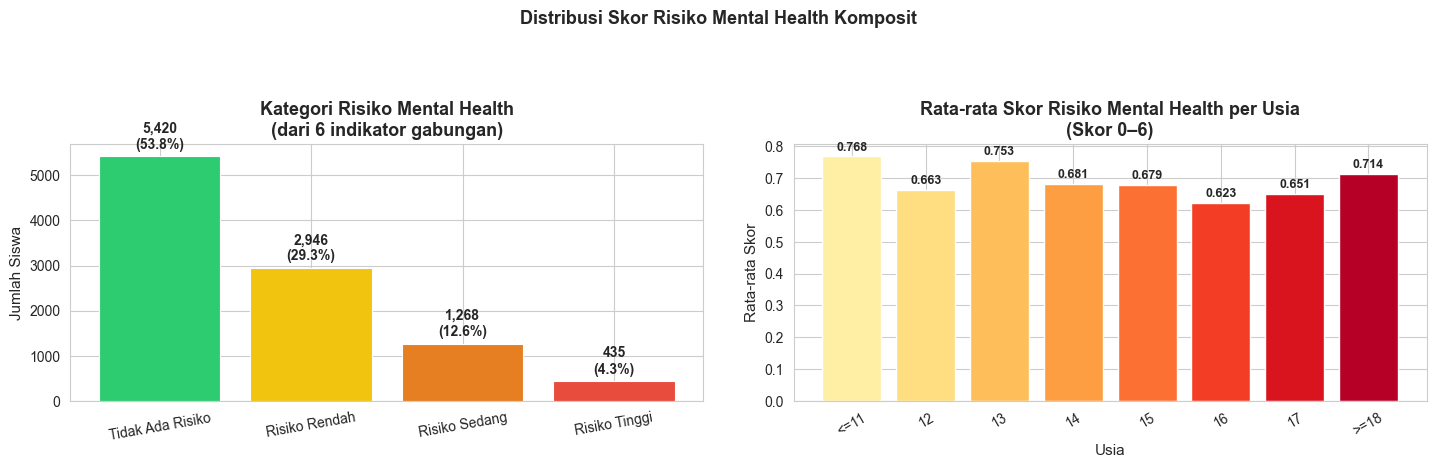

Distribusi Skor Risiko:
  Tidak Ada Risiko      : 5,420 siswa  (53.8%)
  Risiko Rendah         : 2,946 siswa  (29.3%)
  Risiko Sedang         : 1,268 siswa  (12.6%)
  Risiko Tinggi         :   435 siswa  (4.3%)


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

risk_flags = ['QN22','QN23','QN24','QN27','QN20','QN15']

df_temp = df_raw[risk_flags + ['Q1']].dropna().copy()

for col in risk_flags:
    df_temp[col + '_num'] = df_temp[col].map({1: 1, 2: 0})

usia_label = {1: '<=11', 2: '12', 3: '13', 4: '14', 5: '15', 6: '16', 7: '17', 8: '>=18'}
usia_order = ['<=11', '12', '13', '14', '15', '16', '17', '>=18']
df_temp['usia'] = df_temp['Q1'].map(usia_label)

# Hitung skor komposit menggunakan kolom yang sudah di-map menjadi 1 dan 0
risk_cols_num = [col + '_num' for col in risk_flags]
df_temp['mh_risk_score'] = df_temp[risk_cols_num].sum(axis=1)

# Kategorisasi skor risiko
df_temp['mh_risk_cat'] = pd.cut(
    df_temp['mh_risk_score'],
    bins=[-1, 0, 1, 2, 6],
    labels=['Tidak Ada Risiko','Risiko Rendah','Risiko Sedang','Risiko Tinggi']
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    'Distribusi Skor Risiko Mental Health Komposit',
    fontsize=13, fontweight='bold'
)

# Distribusi kategori risiko
cat_order   = ['Tidak Ada Risiko','Risiko Rendah','Risiko Sedang','Risiko Tinggi']
cat_colors  = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
score_counts = df_temp['mh_risk_cat'].value_counts().reindex(cat_order)
total_scored  = score_counts.sum()

bars = axes[0].bar(
    score_counts.index, score_counts.values,
    color=cat_colors, edgecolor='white', linewidth=0.8
)
axes[0].set_title(
    'Kategori Risiko Mental Health\n(dari 6 indikator gabungan)',
    fontweight='bold'
)
axes[0].set_ylabel('Jumlah Siswa')
axes[0].tick_params(axis='x', rotation=10)
for bar, val in zip(bars, score_counts.values):
    if not pd.isna(val):
        axes[0].text(
            bar.get_x() + bar.get_width()/2, bar.get_height() + (score_counts.max() * 0.02), # Menggunakan persentase tinggi max agar dinamis
            f'{int(val):,}\n({val/total_scored*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold'
        )

# Rata-rata skor per usia
avg_score = df_temp.groupby('usia')['mh_risk_score'].mean().reindex(usia_order)

palette_usia = sns.color_palette('YlOrRd', len(usia_order))
bars2 = axes[1].bar(
    avg_score.index, avg_score.values,
    color=palette_usia, edgecolor='white'
)
axes[1].set_title(
    'Rata-rata Skor Risiko Mental Health per Usia\n(Skor 0–6)',
    fontweight='bold'
)
axes[1].set_ylabel('Rata-rata Skor')
axes[1].set_xlabel('Usia')
axes[1].tick_params(axis='x', rotation=30)
for bar, val in zip(bars2, avg_score.values):
    if not pd.isna(val):
        axes[1].text(
            bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

plt.tight_layout(pad=3)
plt.show()

print('Distribusi Skor Risiko:')
for cat, cnt in score_counts.items():
    if not pd.isna(cnt):
        print(f'  {cat:<22}: {int(cnt):5,} siswa  ({cnt/total_scored*100:.1f}%)')